In [24]:
import pandas as pd

In [25]:
df=pd.read_csv("she.csv")
df

,day,Me_sleep,She_sleep,Me_water,She_water,Me_shoping,She_shopping,Me_drama,She_drama,Me_social,She_social,Me_reading,She_reading,Me_words_k,She_words_k
0,Mon,10.0,5.0,2.1,2.0,1,1,1.5,2.0,3.2,4.1,0.8,0.4,8.0,10.0
1,Tue,11.0,7.2,1.9,2.3,1,2,2.0,2.0,4.1,3.5,1.2,0.8,7.1,11.0
2,Wed,8.0,7.5,2.5,2.0,1,5,3.0,1.5,2.8,2.9,1.5,1.2,6.5,12.0
3,Thu,7.2,6.5,2.2,1.7,2,6,1.0,2.5,3.5,4.3,0.7,2.5,6.6,11.0
4,Fri,8.0,8.0,1.8,2.4,2,3,2.5,4.0,4.7,3.8,1.0,2.0,7.0,10.6
5,Sat,8.5,8.2,2.8,2.2,0,5,1.5,5.0,3.0,4.0,2.0,3.0,6.0,11.0
6,Sun,8.0,7.8,2.6,2.4,1,3,1.0,0.5,3.0,5.0,1.8,2.1,6.8,12.0


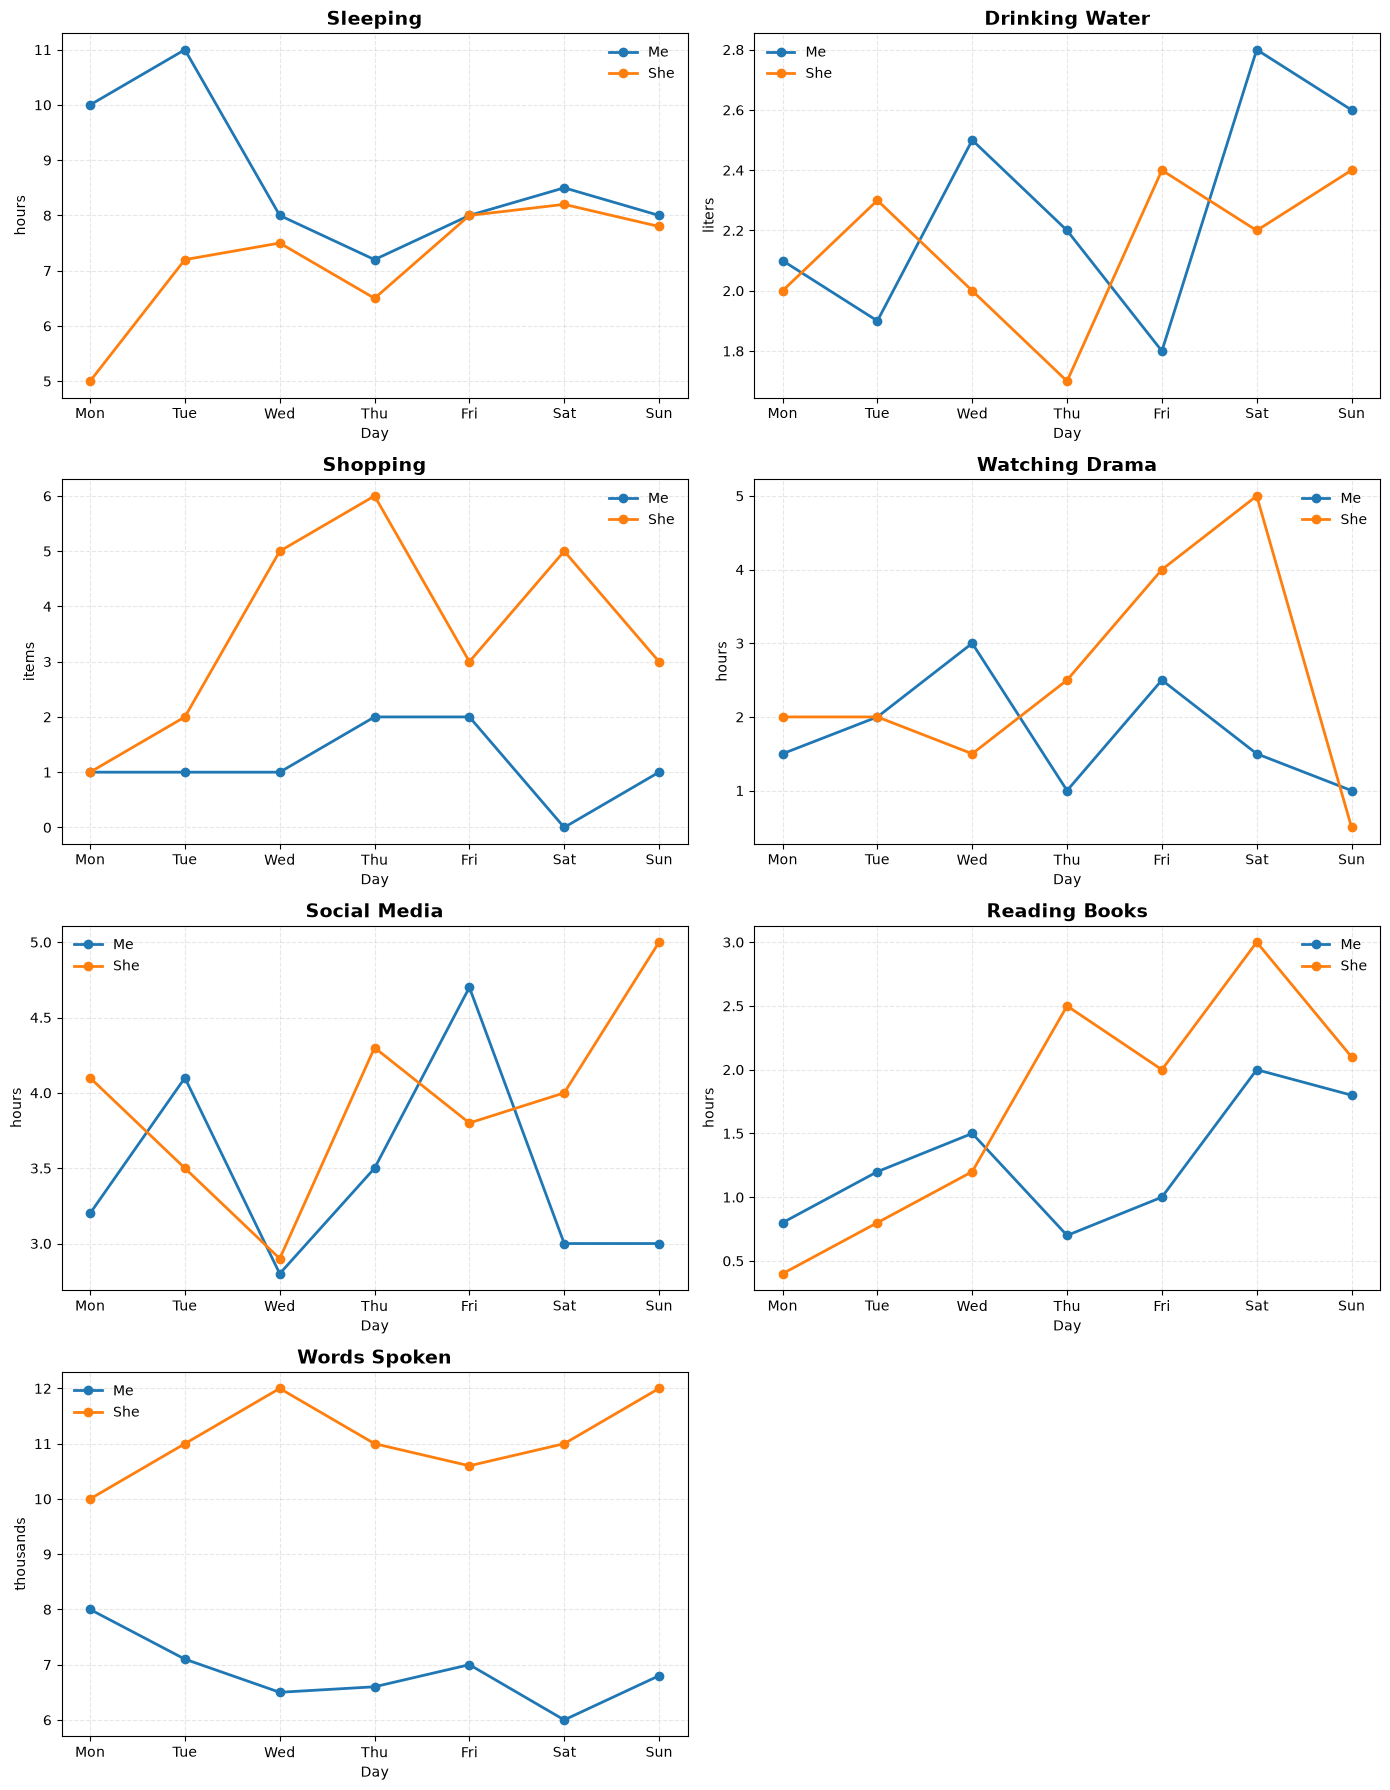

In [26]:
import matplotlib.pyplot as plt

Activities = [
    ("Me_sleep", "She_sleep", "Sleeping", "hours"),
    ("Me_water", "She_water", "Drinking Water", "liters"),
    ("Me_shoping", "She_shopping", "Shopping", "items"),
    ("Me_drama", "She_drama", "Watching Drama", "hours"),
    ("Me_social", "She_social", "Social Media", "hours"),
    ("Me_reading", "She_reading", "Reading Books", "hours"),
    ("Me_words_k", "She_words_k", "Words Spoken", "thousands")
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, (me, she, title, ylabel) in zip(axes, Activities):
    ax.plot(df["day"], df[me],
            marker="o", linewidth=2, label="Me")

    ax.plot(df["day"], df[she],
            marker="o", linewidth=2, label="She")

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Day")
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


In [23]:
correlations = []
for me, she, category,unit in Activities:
    r = df[me].corr(df[she])
    correlations.append({
        "Category": category,
        "Pearson_r": r
    })

correlation_df = pd.DataFrame(correlations)
correlation_df

,Category,Pearson_r
0,Sleeping,-0.359338
1,Drinking Water,-0.071973
2,Shopping,0.057104
3,Watching Drama,0.108253
4,Social Media,-0.114426
5,Reading Books,0.419486
6,Words Spoken,-0.517473


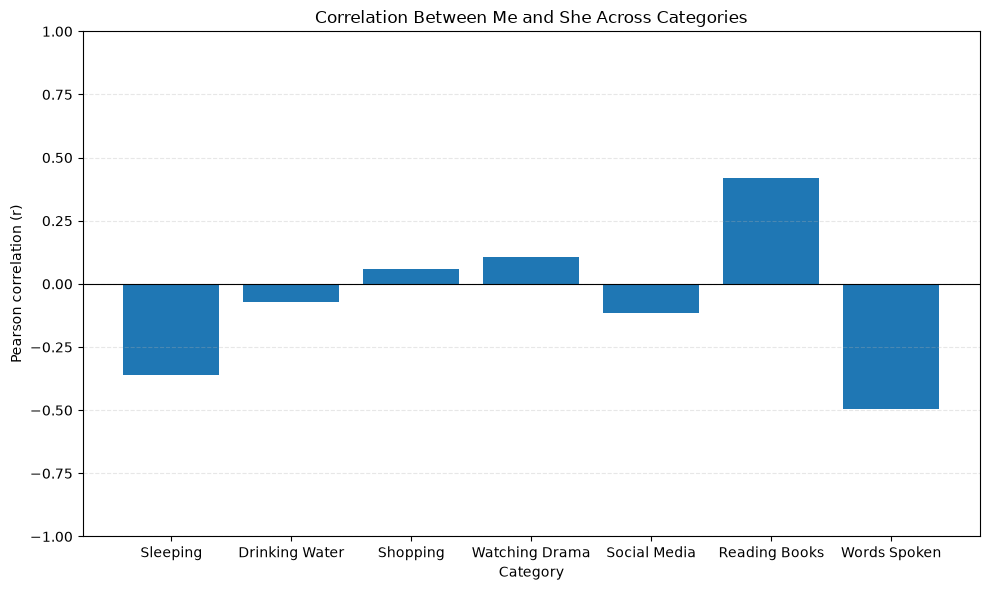

In [19]:
plt.figure(figsize=(10, 6))

plt.bar(correlation_df["Category"],correlation_df["Pearson_r"])

plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Pearson correlation (r)")
plt.xlabel("Category")
plt.title("Correlation Between Me and She Across Categories")
plt.ylim(-1, 1)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


who is lily?

In [ ]:
for me, she, category,unit in Activities:
    r = df[me].corr(df[she])
    if abs(r) < 0.5:
        print(f"{category}: No relationship")
    else:
        print(f"{category}: Relationship")
